In [1]:
library(tidyverse)
library(qqman)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   4.0.0     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


For example usage please run: vignette('qqman')



Citation appreciated but not required:

Turner, (2018). qqman: an R package for visualizing GWAS results using Q-Q and manhattan plots. Journal of Open Source Software, 3(25), 731, https://doi.org/10.21105/joss.00731.





In [2]:
library(ggrepel)

In [3]:
gwas <- read_table("data/GWAS_LogisticRegression.assoc.logistic") %>%
  filter(TEST == "ADD") %>%
  filter(!is.na(P)) %>%
  filter(P > 0)          # remove P = 0 which causes -log10 issues

gwas_clean <- gwas %>%
  filter(CHR %in% 1:22) %>%          # autosomes only
  mutate(
    CHR = as.integer(CHR),
    BP  = as.integer(BP),
    P   = as.numeric(P)
  ) %>%
  arrange(CHR, BP)

Warning message:
“Missing column names filled in: 'X10' [10]”

── Column specification ────────────────────────────────────────────────────────
cols(
  CHR = col_double(),
  SNP = col_character(),
  BP = col_double(),
  A1 = col_character(),
  TEST = col_character(),
  NMISS = col_double(),
  OR = col_double(),
  STAT = col_double(),
  P = col_double(),
  X10 = col_character()
)

Warning message:
“1772012 parsing failures.
row col   expected    actual                                          file
  1  -- 10 columns 9 columns 'data/GWAS_LogisticRegression.assoc.logistic'
  2  -- 10 columns 9 columns 'data/GWAS_LogisticRegression.assoc.logistic'
  3  -- 10 columns 9 columns 'data/GWAS_LogisticRegression.assoc.logistic'
  4  -- 10 columns 9 columns 'data/GWAS_LogisticRegression.assoc.logistic'
  5  -- 10 columns 9 columns 'data/GWAS_LogisticRegression.assoc.logistic'
... ... .......... ......... .............................................
See problems(...) for more details.
”


In [5]:
options(repr.plot.width=9, repr.plot.height=4, repr.plot.res =600)

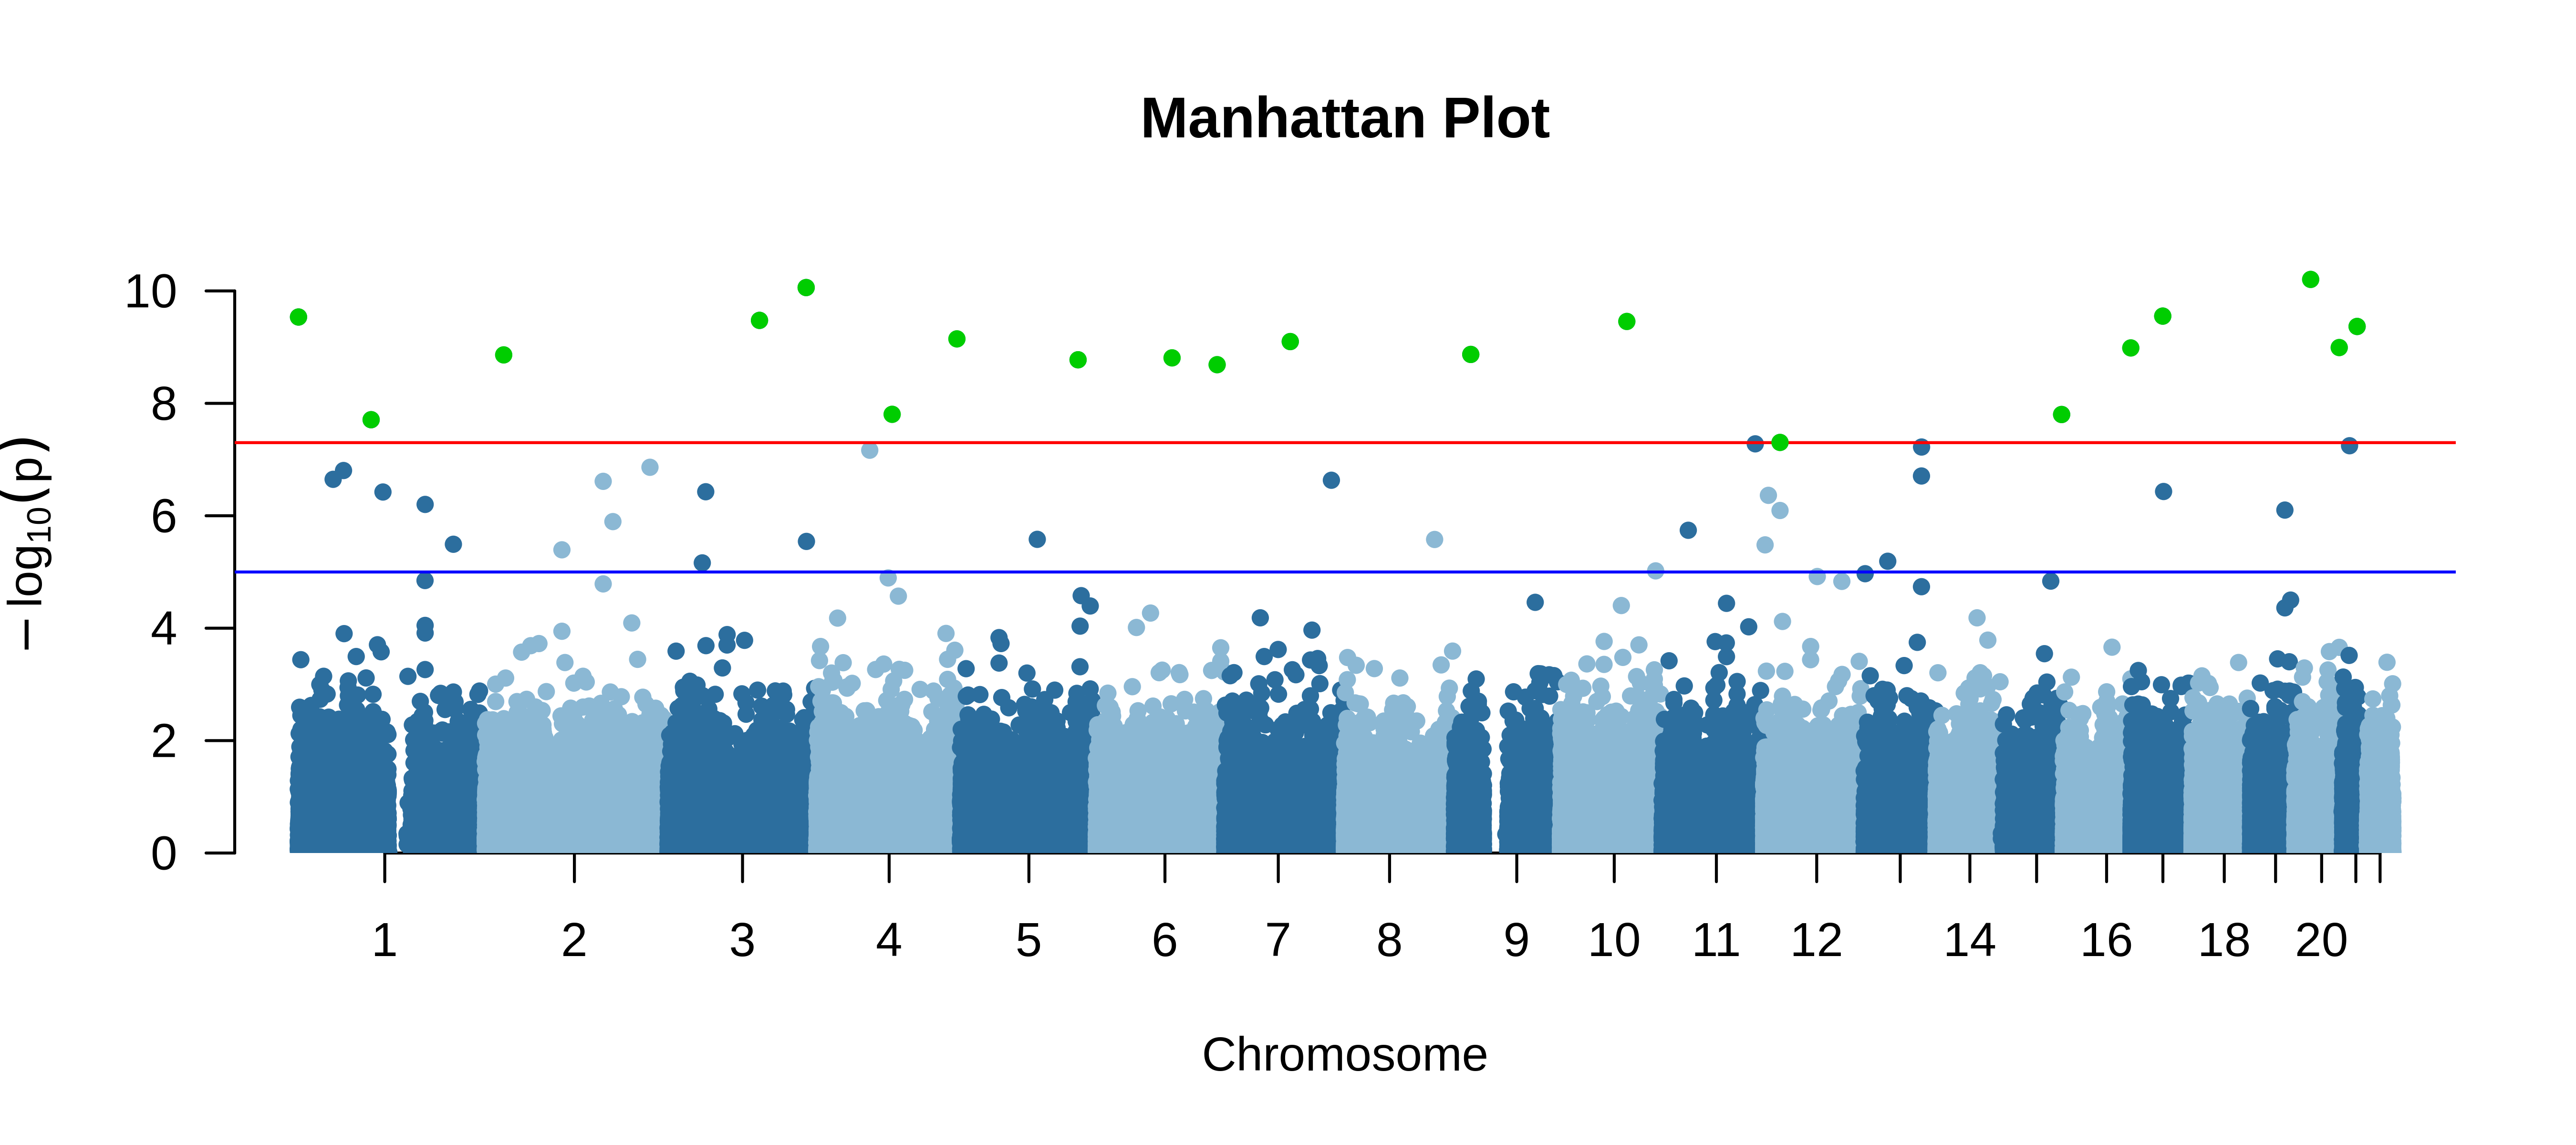

In [6]:
manhattan(
  gwas_clean,
  chr     = "CHR",
  bp      = "BP",
  snp     = "SNP",
  p       = "P",
  
  # significance lines
  genomewideline = -log10(5e-8),     # genome-wide threshold
  suggestiveline = -log10(1e-5),     # suggestive threshold
  
  # colours - alternating chromosomes
  col     = c("#2C6E9E", "#8BB8D4"),
  
  # labels
  main    = "Manhattan Plot",
  xlab    = "Chromosome",
  ylab    = expression(-log[10](p)),
  
  # highlight genome-wide significant SNPs
  highlight = gwas_clean %>% 
    filter(P < 5e-8) %>% 
    pull(SNP),
  
  chrlabs = as.character(1:22)
)

Rows: 862 Columns: 6
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr (3): CHR, band, stain
dbl (3): start, end, score

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `CHR = as.integer(str_remove(CHR, "chr"))`.
Caused by warning:
! NAs introduced by coercion”


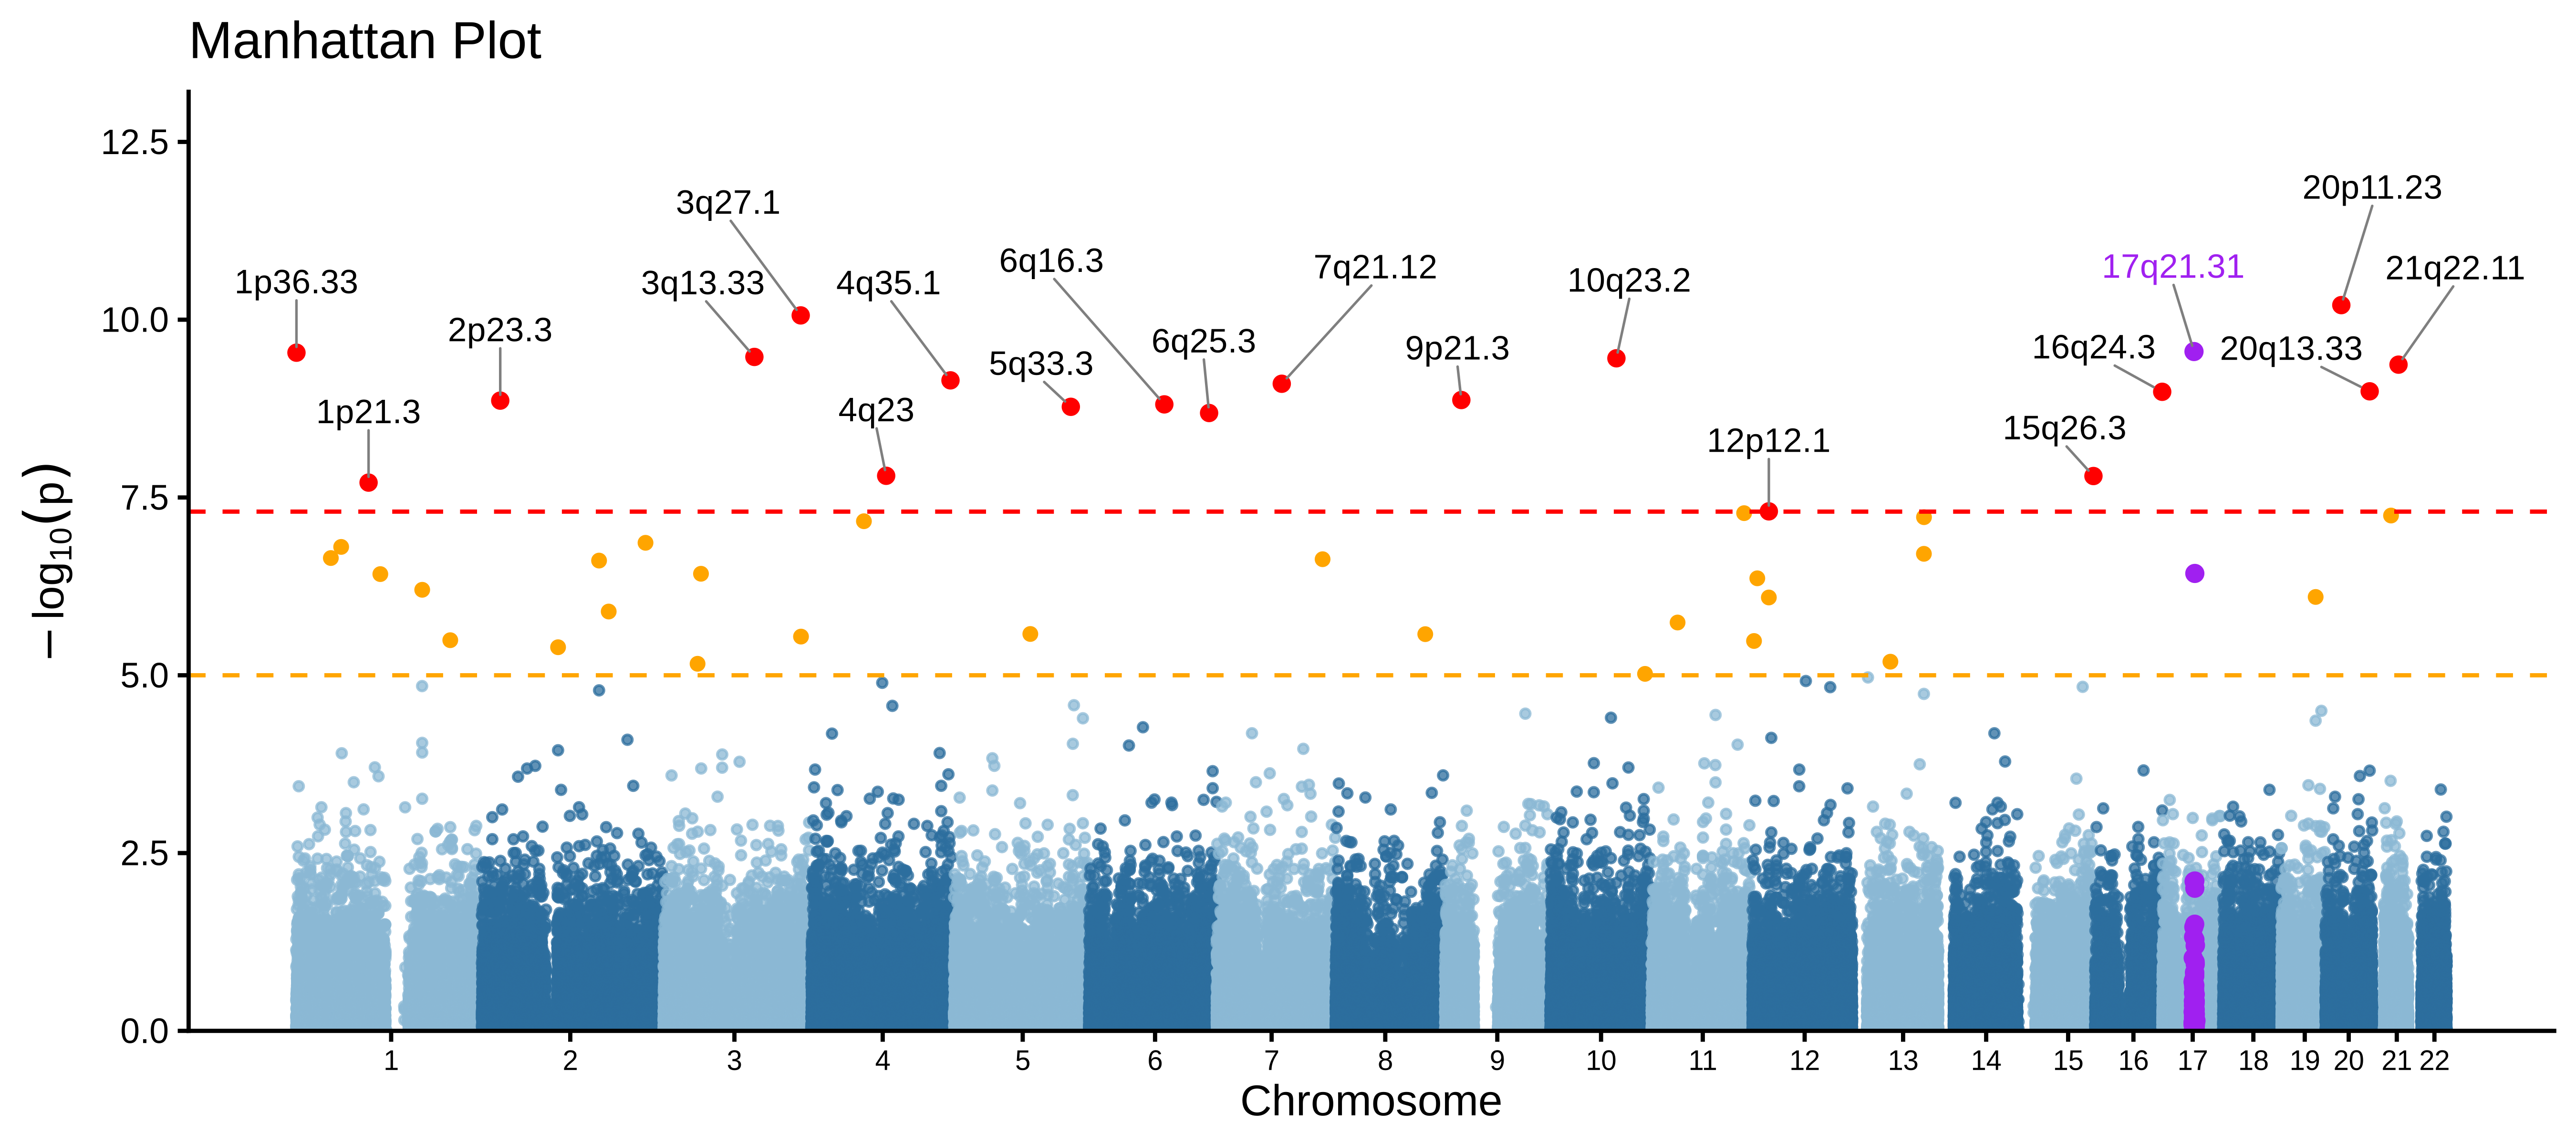

In [8]:
manhattan_data <- gwas_clean %>%
  group_by(CHR) %>%
  summarise(chr_len = max(BP)) %>%
  mutate(tot = cumsum(as.numeric(chr_len)) - as.numeric(chr_len)) %>%
  left_join(gwas_clean, ., by = "CHR") %>%
  mutate(
    bp_cum = as.numeric(BP) + tot,
    sig    = P < 5e-8,
    sugg   = P < 1e-5 & P >= 5e-8
  )

# load cytoband data
cytoband <- read_tsv("cytoBand_ucsc_hg19.bed", col_names = c("CHR", "start", "end", "band", "score", "stain")) %>%
  mutate(CHR = as.integer(str_remove(CHR, "chr"))) %>%
  filter(!is.na(CHR))       

find_cytoband <- function(chr, bp, cytoband) {
  band <- cytoband %>%
    filter(CHR == chr, start <= bp, end >= bp) %>%
    pull(band)
  if (length(band) == 0) return(NA)
  return(paste0(chr, band[1]))       # e.g. "1p36.33"
}

lead_snps <- manhattan_data %>%
  filter(P < 5e-8) %>%
  mutate(label = SNP) %>%
  rowwise() %>%
  mutate(
    cytoband_label = find_cytoband(CHR, BP, cytoband)
  ) %>%
  ungroup() %>%
  mutate(label = cytoband_label)     # use cytoband as label


# highlight 17q21.31
region_17q21 <- cytoband %>%
  filter(CHR == 17, band == "q21.31") %>%
  summarise(start = min(start), end = max(end))

manhattan_data <- manhattan_data %>%
  mutate(in_17q21 = CHR == 17 & BP >= region_17q21$start & BP <= region_17q21$end)

# plot
axis_data <- manhattan_data %>%
  group_by(CHR) %>%
  summarise(centre = mean(bp_cum))

ggplot(manhattan_data, aes(x = bp_cum, y = -log10(P))) +
  geom_point(aes(colour = as.factor(CHR %% 2)),
             size = 0.8, alpha = 0.75, show.legend = FALSE) +
  scale_colour_manual(values = c("0" = "#2C6E9E", "1" = "#8BB8D4")) +
  geom_point(data = filter(manhattan_data, sugg),
             colour = "orange", size = 1.2) +
  geom_point(data = filter(manhattan_data, sig),
            colour = "red", size = 1.5) +
  geom_point(data = filter(manhattan_data, in_17q21), 
             colour = "purple", size = 1.6) +
  geom_hline(yintercept = -log10(5e-8),
             linetype = "dashed", colour = "red",    linewidth = 0.5) +
  geom_hline(yintercept = -log10(1e-5),
             linetype = "dashed", colour = "orange", linewidth = 0.5) +
geom_text_repel(
    data               = lead_snps,
    aes(label          = label),
    size               = 3,
    colour             = ifelse(lead_snps$label == "17q21.31", "purple", "black"),
    box.padding        = 0.5,
    point.padding      = 0.3,
    segment.color      = "grey50",
    segment.size       = 0.3,
    max.overlaps       = Inf,
    min.segment.length = 0,
    nudge_y            = 1
  ) +
  scale_x_continuous(
    label  = axis_data$CHR,
    breaks = axis_data$centre
  ) +
  scale_y_continuous(
    expand = c(0, 0),
    limits = c(0, max(-log10(manhattan_data$P)) + 3)
  ) +
  labs(
    title = "Manhattan Plot",
    x     = "Chromosome",
    y     = expression(-log[10](p))
  ) +
  theme_classic() +
  theme(
    axis.text.x      = element_text(size = 7),
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank()
  )